# Advanced PADR-Net Workflow: Transfer, Uncertainty, and Stress Testing

> **Goal**: use `PADRNet` as an experiment framework, not only as a
> single forecaster. We run leave-one-region-out transfer, physics-loss
> ablation, threshold calibration, Monte-Carlo dropout uncertainty, and
> rainfall-intensification stress tests.

This notebook is the advanced companion to
`14_padrnet_flood_forecasting.ipynb`.


In [1]:
import os
import warnings

warnings.filterwarnings("ignore")
os.environ.setdefault("BASE_ATTENTIVE_BACKEND", "tensorflow")
os.environ.setdefault("KERAS_BACKEND", "tensorflow")
print("BASE_ATTENTIVE_BACKEND =", os.environ["BASE_ATTENTIVE_BACKEND"])
print("KERAS_BACKEND =", os.environ["KERAS_BACKEND"])


BASE_ATTENTIVE_BACKEND = tensorflow
KERAS_BACKEND = tensorflow


---

## 1. Imports

The public API remains small: `PADRNetConfig` validates the model
configuration and `PADRNet` creates the backend-specific model. The
advanced workflow is built around experimental splits and diagnostics.


In [2]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from base_attentive import PADRNet, PADRNetConfig
from base_attentive.applications.flood import (
    critical_success_index,
    delta_mass,
    linear_reservoir_response,
    mass_balance_residual,
    nash_sutcliffe_efficiency,
    true_skill_statistic,
)

np.random.seed(123)
tf.random.set_seed(123)
tf.get_logger().setLevel("ERROR")
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})


---

## 2. Regional Synthetic Data with Transfer Shift

The generator makes WAF, EAF, and SAF hydrologically different. That
regional shift is what makes transfer testing meaningful.


In [3]:
@dataclass(frozen=True)
class RegionSpec:
    code: str
    name: str
    color: str
    tau: float
    gain: float
    area: float
    slope: float
    impervious: float
    storm_scale: float
    convective: float

REGIONS = [
    RegionSpec("WAF", "West Africa", "#1f66b1", 30.0, 0.020, 0.74, 0.34, 0.23, 1.18, 0.70),
    RegionSpec("EAF", "East Africa", "#f05a28", 19.0, 0.018, 0.55, 0.55, 0.18, 1.02, 1.10),
    RegionSpec("SAF", "South Africa", "#2f8f3b", 36.0, 0.015, 0.63, 0.30, 0.15, 0.92, 0.55),
]
LOOKBACK, HORIZON = 48, 24
TOTAL_STEPS = LOOKBACK + HORIZON
INPUT_DIM, STATIC_DIM = 8, 3
FLOOD_THRESHOLD = 0.08
GAIN_PROXY = 0.12


def rolling_mean(v, w):
    return np.convolve(v, np.ones(w) / w, mode="same")


def make_storm(rng, spec, intensify=1.0):
    t = np.arange(TOTAL_STEPS)
    rain = rng.gamma(1.15, 0.10, TOTAL_STEPS)
    for _ in range(rng.integers(1, 4)):
        c = rng.uniform(10, LOOKBACK + 10)
        width = rng.uniform(2.2, 7.5)
        height = rng.uniform(1.1, 4.4) * spec.storm_scale * intensify
        rain += height * np.exp(-0.5 * ((t - c) / width) ** 2)
    if rng.random() < spec.convective:
        c = rng.uniform(LOOKBACK - 5, LOOKBACK + 8)
        rain += 1.5 * intensify * np.exp(-0.5 * ((t - c) / 1.8) ** 2)
    return np.maximum(rain, 0.0)


def make_event(rng, spec, year, intensify=1.0):
    rain = make_storm(rng, spec, intensify)
    depth = linear_reservoir_response(rain, tau=spec.tau, gain=spec.gain)
    depth = 8.0 * depth + 0.014 * np.sin(np.linspace(0, 2 * np.pi, TOTAL_STEPS))
    depth += rng.normal(0.0, 0.004, TOTAL_STEPS)
    depth = np.maximum(depth, 0.0)
    fast = linear_reservoir_response(rain, tau=max(8.0, spec.tau * 0.6), gain=spec.gain * 0.8)
    hour = np.arange(TOTAL_STEPS) / 24.0
    dyn = np.column_stack([
        rain, rolling_mean(rain, 6), rolling_mean(rain, 18), fast,
        np.sin(2 * np.pi * hour), np.cos(2 * np.pi * hour),
        np.full(TOTAL_STEPS, (year - 2001) / 24.0), np.gradient(rain),
    ])
    return {
        "region": spec.code,
        "year": year,
        "x": dyn[:LOOKBACK].astype("float32"),
        "static": np.array([spec.area, spec.slope, spec.impervious], dtype="float32"),
        "y": depth[LOOKBACK:].astype("float32")[:, None],
        "p": rain[LOOKBACK:].astype("float32")[:, None],
    }


def make_dataset(n=540, seed=33, intensify=1.0):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n):
        spec = REGIONS[int(rng.integers(0, len(REGIONS)))]
        out.append(make_event(rng, spec, int(rng.integers(2001, 2025)), intensify))
    return out


def arrays(events):
    return {
        "X": np.stack([e["x"] for e in events]).astype("float32"),
        "S": np.stack([e["static"] for e in events]).astype("float32"),
        "Y": np.stack([e["y"] for e in events]).astype("float32"),
        "P": np.stack([e["p"] for e in events]).astype("float32"),
        "region": np.array([e["region"] for e in events]),
        "year": np.array([e["year"] for e in events]),
    }

data = arrays(make_dataset())
print(data["X"].shape, data["S"].shape, data["Y"].shape)


(540, 48, 8) (540, 3) (540, 24, 1)


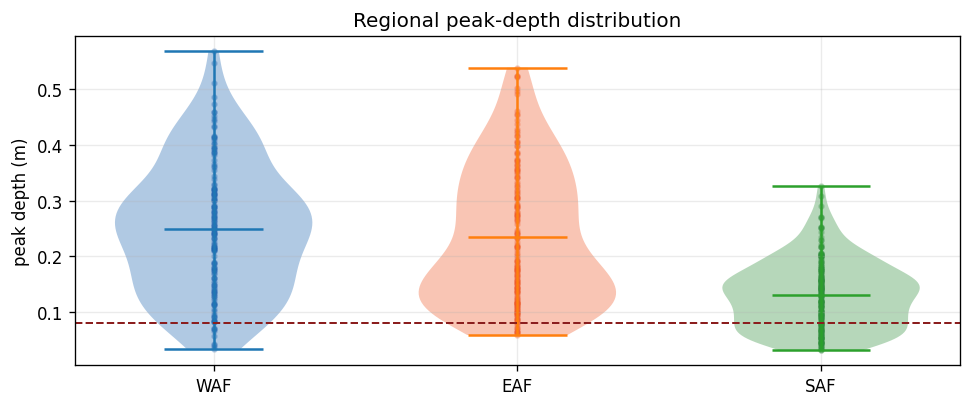

In [4]:
peaks = data["Y"].max(axis=(1, 2))
fig, ax = plt.subplots(figsize=(8.2, 3.5))
for i, spec in enumerate(REGIONS):
    vals = peaks[data["region"] == spec.code]
    parts = ax.violinplot(vals, positions=[i], widths=0.65, showmeans=True)
    for body in parts["bodies"]:
        body.set_facecolor(spec.color); body.set_alpha(0.35)
    ax.scatter(np.full(vals.size, i), vals, s=8, color=spec.color, alpha=0.28)
ax.axhline(FLOOD_THRESHOLD, color="#8b1e1e", ls="--", lw=1.2)
ax.set_xticks(range(3), [r.code for r in REGIONS])
ax.set_ylabel("peak depth (m)")
ax.set_title("Regional peak-depth distribution")
fig.tight_layout(); plt.show()


---

## 3. Reusable Experiment Helpers

These helpers keep the workflow compact. The model returns a dictionary,
so the training loop explicitly uses the `depth` output and combines MSE
with hydrological residual, mass-bias, and smoothness penalties.


In [5]:
def make_config(lambda_physics=0.25, lambda_mass=0.05, dropout=0.08):
    return PADRNetConfig(
        input_dim=INPUT_DIM, static_dim=STATIC_DIM, hidden_dim=48,
        num_heads=4, num_layers=2, forecast_horizon=HORIZON,
        dropout=dropout, lambda_physics=lambda_physics,
        lambda_mass=lambda_mass, lambda_smooth=0.01,
        flood_threshold=FLOOD_THRESHOLD, reservoir_tau=24.0,
    )


def ds(a, idx, batch=48, shuffle=False):
    out = tf.data.Dataset.from_tensor_slices((a["X"][idx], a["S"][idx], a["Y"][idx], a["P"][idx]))
    if shuffle:
        out = out.shuffle(len(idx), seed=123, reshuffle_each_iteration=True)
    return out.batch(batch).prefetch(tf.data.AUTOTUNE)


def optimizer():
    try:
        return tf.keras.optimizers.Adam(3e-3)
    except (ImportError, ModuleNotFoundError):
        from tensorflow.python.keras.optimizer_v2.adam import Adam
        return Adam(3e-3)


def loss_terms(y, pred, rain, cfg):
    h = tf.squeeze(pred, -1); y = tf.squeeze(y, -1); p = tf.squeeze(rain, -1)
    mse = tf.reduce_mean(tf.square(y - h))
    dh = h[:, 1:] - h[:, :-1]
    residual = dh - (GAIN_PROXY * p[:, 1:] - h[:, :-1] / cfg.reservoir_tau)
    physics = tf.reduce_mean(tf.square(residual))
    mass = tf.reduce_mean(tf.abs(tf.reduce_sum(h, 1) - tf.reduce_sum(y, 1)) / (tf.reduce_sum(y, 1) + 1e-4))
    smooth = tf.reduce_mean(tf.square(dh))
    total = mse + cfg.lambda_physics * physics + cfg.lambda_mass * mass + cfg.lambda_smooth * smooth
    return total, {"mse": mse, "physics": physics, "mass": mass, "smooth": smooth}


def train_model(a, train_idx, val_idx, cfg, epochs=12, verbose=False):
    model = PADRNet(cfg, backend="tensorflow")
    _ = model(tf.zeros((1, LOOKBACK, INPUT_DIM)), tf.zeros((1, STATIC_DIM)))
    opt = optimizer()
    train_ds, val_ds = ds(a, train_idx, shuffle=True), ds(a, val_idx)
    hist = {"train": [], "val": [], "mse": [], "physics": [], "mass": []}

    @tf.function
    def train_step(xb, sb, yb, pb):
        with tf.GradientTape() as tape:
            out = model(xb, sb, training=True)
            loss, parts = loss_terms(yb, out["depth"], pb, cfg)
        opt.apply_gradients(zip(tape.gradient(loss, model.trainable_variables), model.trainable_variables))
        return loss, parts

    @tf.function
    def eval_step(xb, sb, yb, pb):
        out = model(xb, sb, training=False)
        return loss_terms(yb, out["depth"], pb, cfg)

    def mean_epoch(data_ds, train=False):
        losses, parts = [], {"mse": [], "physics": [], "mass": []}
        for xb, sb, yb, pb in data_ds:
            loss, detail = train_step(xb, sb, yb, pb) if train else eval_step(xb, sb, yb, pb)
            losses.append(float(loss.numpy()))
            for k in parts: parts[k].append(float(detail[k].numpy()))
        return float(np.mean(losses)), {k: float(np.mean(v)) for k, v in parts.items()}

    for epoch in range(1, epochs + 1):
        tr, _ = mean_epoch(train_ds, train=True)
        va, detail = mean_epoch(val_ds)
        hist["train"].append(tr); hist["val"].append(va)
        for k in ["mse", "physics", "mass"]: hist[k].append(detail[k])
        if verbose and (epoch == 1 or epoch == epochs or epoch % 5 == 0):
            print(f"epoch {epoch:02d} train={tr:.4f} val={va:.4f}")
    return model, hist


def predict(model, a, idx, training=False):
    out = model(tf.convert_to_tensor(a["X"][idx]), tf.convert_to_tensor(a["S"][idx]), training=training)
    return out["depth"].numpy(), out["exceedance_probability"].numpy(), out["features"].numpy()


def score(y, pred, threshold=FLOOD_THRESHOLD):
    yt, yp = y.reshape(-1), pred.reshape(-1)
    return {
        "NSE": nash_sutcliffe_efficiency(yt, yp),
        "CSI": critical_success_index(yt, yp, threshold=threshold),
        "TSS": true_skill_statistic(yt, yp, threshold=threshold),
        "DeltaM": delta_mass(yt, yp),
        "RMSE": float(np.sqrt(np.mean((yt - yp) ** 2))),
    }


---

## 4. Baseline Temporal Split

This baseline is the reference for the harder transfer and ablation
experiments.


In [6]:
years = data["year"]
train_idx = np.where(years <= 2018)[0]
val_idx = np.where((years >= 2019) & (years <= 2020))[0]
test_idx = np.where(years >= 2021)[0]

base_cfg = make_config()
base_model, base_hist = train_model(data, train_idx, val_idx, base_cfg, epochs=16, verbose=True)
base_pred, base_prob, base_feat = predict(base_model, data, test_idx)
base_score = score(data["Y"][test_idx], base_pred)
base_score


epoch 01 train=0.4231 val=0.1593
epoch 05 train=0.0568 val=0.0496
epoch 10 train=0.0407 val=0.0301
epoch 15 train=0.0333 val=0.0259
epoch 16 train=0.0305 val=0.0293


{'NSE': 0.5295109002287013,
 'CSI': 0.7997227997227997,
 'TSS': 0.6785502958579881,
 'DeltaM': -16.995160313730974,
 'RMSE': 0.06130300089716911}

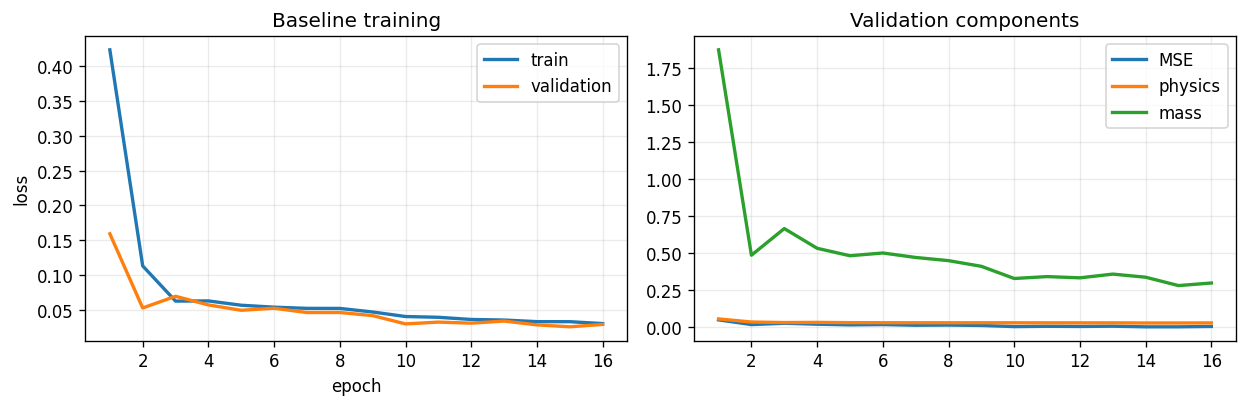

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.5))
e = np.arange(1, len(base_hist["train"]) + 1)
axes[0].plot(e, base_hist["train"], label="train", lw=2)
axes[0].plot(e, base_hist["val"], label="validation", lw=2)
axes[0].set_title("Baseline training")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[1].plot(e, base_hist["mse"], label="MSE", lw=2)
axes[1].plot(e, base_hist["physics"], label="physics", lw=2)
axes[1].plot(e, base_hist["mass"], label="mass", lw=2)
axes[1].set_title("Validation components"); axes[1].legend()
fig.tight_layout(); plt.show()


---

## 5. Leave-One-Region-Out Transfer

Train on two regions and test on the held-out target region. This is a
stronger diagnostic than a random split because it tests regional
transfer.


In [8]:
transfer = []
for target in [r.code for r in REGIONS]:
    source = data["region"] != target
    target_mask = data["region"] == target
    tr = np.where(source & (years <= 2019))[0]
    va = np.where(source & (years == 2020))[0]
    te = np.where(target_mask & (years >= 2021))[0]
    m, _ = train_model(data, tr, va, make_config(), epochs=10)
    p, _, _ = predict(m, data, te)
    row = score(data["Y"][te], p); row.update({"target": target, "n": len(te)})
    transfer.append(row)

for r in transfer:
    print(f"hold out {r['target']}: NSE={r['NSE']:.3f} CSI={r['CSI']:.3f} TSS={r['TSS']:.3f} DeltaM={r['DeltaM']:.1f}%")


hold out WAF: NSE=-0.254 CSI=0.701 TSS=0.459 DeltaM=-41.6%
hold out EAF: NSE=-0.564 CSI=0.632 TSS=0.012 DeltaM=-49.1%
hold out SAF: NSE=0.215 CSI=0.636 TSS=0.309 DeltaM=0.4%


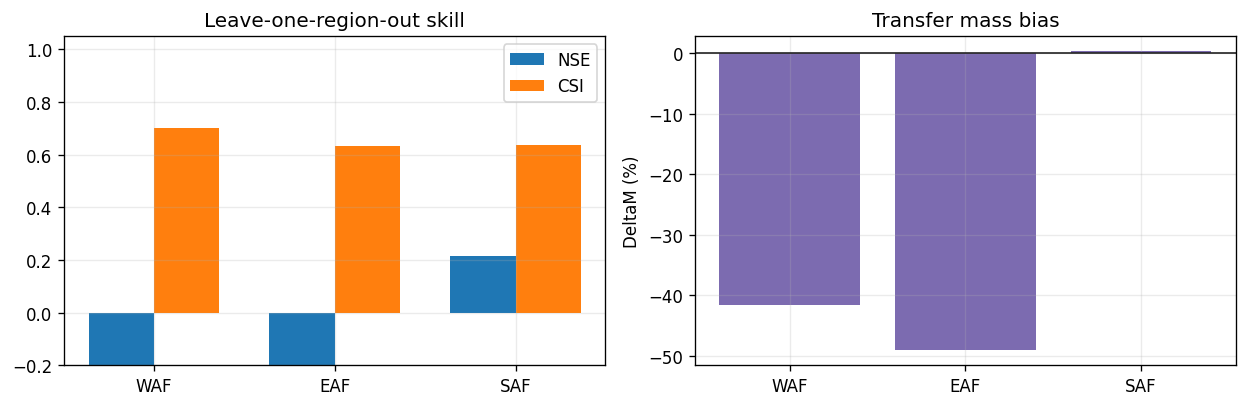

In [9]:
labels = [r["target"] for r in transfer]
x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.5))
axes[0].bar(x - 0.18, [r["NSE"] for r in transfer], 0.36, label="NSE")
axes[0].bar(x + 0.18, [r["CSI"] for r in transfer], 0.36, label="CSI")
axes[0].set_xticks(x, labels); axes[0].set_ylim(-0.2, 1.05)
axes[0].set_title("Leave-one-region-out skill"); axes[0].legend()
axes[1].bar(labels, [r["DeltaM"] for r in transfer], color="#7c6bb0")
axes[1].axhline(0, color="#222", lw=1); axes[1].set_ylabel("DeltaM (%)")
axes[1].set_title("Transfer mass bias")
fig.tight_layout(); plt.show()


---

## 6. Physics-Loss Ablation

A reviewer may ask whether the physics term helps. We compare the
physics-aware model against the same architecture with physics and mass
terms set to zero.


In [10]:
ablation = []
for name, cfg in [("PADR-Net", make_config(0.25, 0.05)), ("No physics", make_config(0.0, 0.0))]:
    m, _ = train_model(data, train_idx, val_idx, cfg, epochs=12)
    p, _, _ = predict(m, data, test_idx)
    row = score(data["Y"][test_idx], p)
    resid = mass_balance_residual(data["P"][test_idx, :, 0], p[:, :, 0], tau=cfg.reservoir_tau, gain=GAIN_PROXY)
    row.update({"model": name, "ResidualRMSE": float(np.sqrt(np.mean(resid**2)))})
    ablation.append(row)

for r in ablation:
    print(f"{r['model']:10s} NSE={r['NSE']:.3f} CSI={r['CSI']:.3f} DeltaM={r['DeltaM']:.1f}% residual={r['ResidualRMSE']:.4f}")


PADR-Net   NSE=0.217 CSI=0.651 DeltaM=-25.5% residual=0.1755
No physics NSE=0.475 CSI=0.747 DeltaM=0.9% residual=0.1758


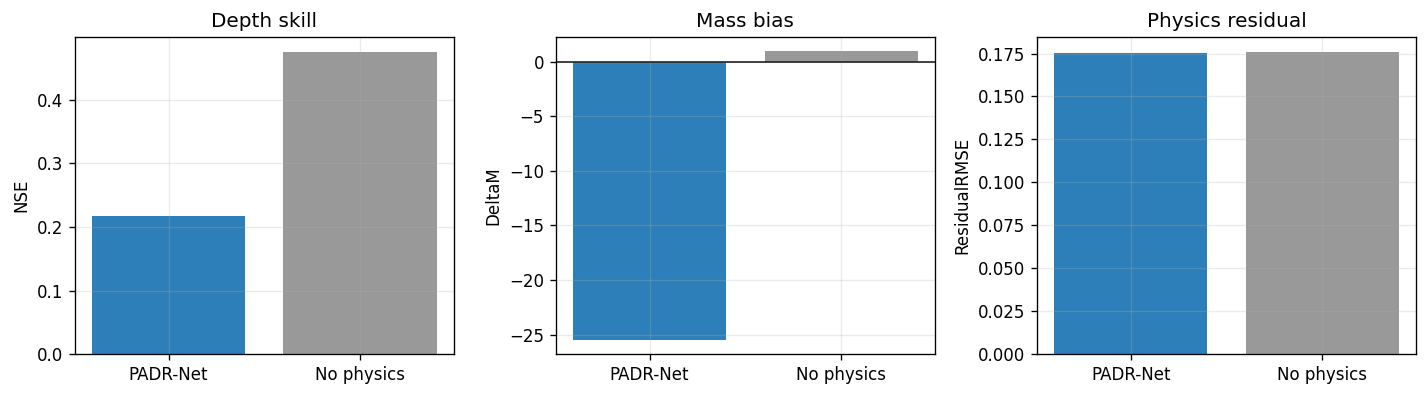

In [11]:
labels = [r["model"] for r in ablation]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, key, title in zip(axes, ["NSE", "DeltaM", "ResidualRMSE"], ["Depth skill", "Mass bias", "Physics residual"]):
    ax.bar(labels, [r[key] for r in ablation], color=["#2c7fb8", "#999999"])
    ax.set_title(title); ax.set_ylabel(key)
    if key == "DeltaM": ax.axhline(0, color="#222", lw=1)
fig.tight_layout(); plt.show()


---

## 7. Threshold Calibration

Warning performance depends on the flood threshold. We scan thresholds
and compare CSI/TSS.


best CSI threshold: 0.03
best TSS threshold: 0.088


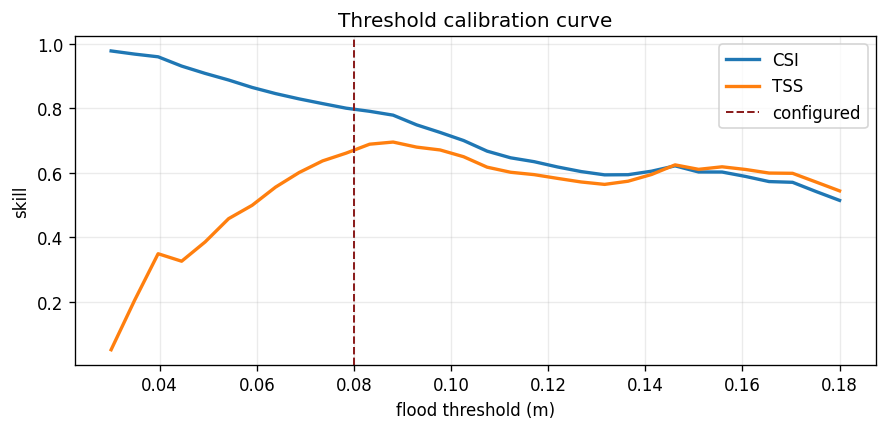

In [12]:
thresholds = np.linspace(0.03, 0.18, 32)
csi = [critical_success_index(data["Y"][test_idx], base_pred, threshold=t) for t in thresholds]
tss = [true_skill_statistic(data["Y"][test_idx], base_pred, threshold=t) for t in thresholds]
print("best CSI threshold:", round(float(thresholds[int(np.argmax(csi))]), 3))
print("best TSS threshold:", round(float(thresholds[int(np.argmax(tss))]), 3))
fig, ax = plt.subplots(figsize=(7.5, 3.7))
ax.plot(thresholds, csi, lw=2, label="CSI")
ax.plot(thresholds, tss, lw=2, label="TSS")
ax.axvline(FLOOD_THRESHOLD, color="#8b1e1e", ls="--", lw=1.2, label="configured")
ax.set_xlabel("flood threshold (m)"); ax.set_ylabel("skill")
ax.set_title("Threshold calibration curve"); ax.legend()
fig.tight_layout(); plt.show()


---

## 8. Monte-Carlo Dropout Uncertainty

Calling PADR-Net with `training=True` at inference activates dropout and
creates a lightweight epistemic uncertainty diagnostic.


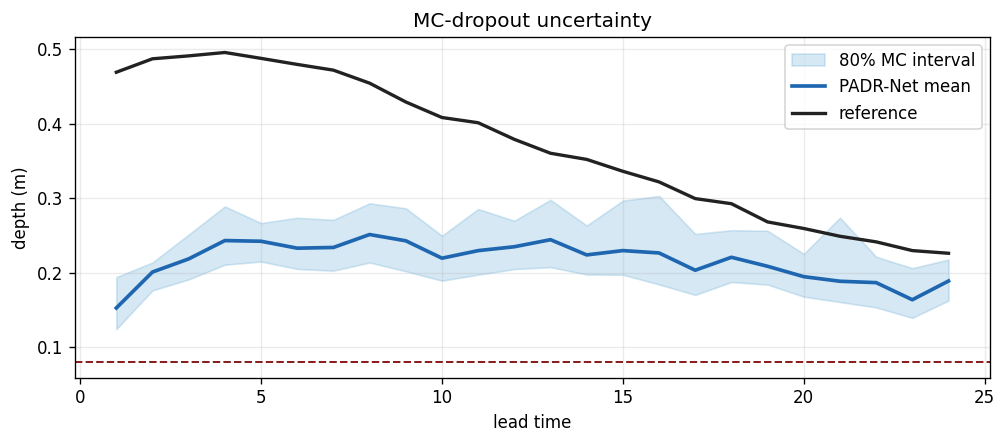

In [13]:
def mc_predict(model, a, idx, n=30):
    samples = [predict(model, a, idx, training=True)[0] for _ in range(n)]
    samples = np.stack(samples)
    return samples.mean(0), np.quantile(samples, [0.1, 0.9], axis=0)

sample_idx = test_idx[:40]
mc_mean, mc_q = mc_predict(base_model, data, sample_idx, n=30)
local = int(np.argmax(data["Y"][sample_idx].max(axis=(1, 2))))
t = np.arange(1, HORIZON + 1)
ref = data["Y"][sample_idx[local], :, 0]
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.fill_between(t, mc_q[0, local, :, 0], mc_q[1, local, :, 0], color="#6baed6", alpha=0.28, label="80% MC interval")
ax.plot(t, mc_mean[local, :, 0], color="#1f66b1", lw=2.2, label="PADR-Net mean")
ax.plot(t, ref, color="#222", lw=2.0, label="reference")
ax.axhline(FLOOD_THRESHOLD, color="#8b1e1e", ls="--", lw=1.2)
ax.set_xlabel("lead time"); ax.set_ylabel("depth (m)")
ax.set_title("MC-dropout uncertainty"); ax.legend()
fig.tight_layout(); plt.show()


---

## 9. Rainfall-Intensification Stress Test

We perturb rainfall intensity and check whether predicted peak depth and
exceedance probability respond monotonically.


In [14]:
scenario_events, factors = [], []
for factor in [1.0, 1.25, 1.50]:
    ev = make_dataset(n=100, seed=int(100 * factor), intensify=factor)
    scenario_events.extend(ev); factors.extend([factor] * len(ev))
scenario = arrays(scenario_events)
factors = np.array(factors)
spred, sprob, _ = predict(base_model, scenario, np.arange(len(factors)))
rows = []
for factor in [1.0, 1.25, 1.50]:
    mask = factors == factor
    rows.append({
        "factor": factor,
        "reference": float(scenario["Y"][mask].max(axis=(1, 2)).mean()),
        "pred": float(spred[mask].max(axis=(1, 2)).mean()),
        "exceed": float((sprob[mask] > 0.5).mean()),
    })
for r in rows:
    print(f"x{r['factor']:.2f}: ref={r['reference']:.3f} pred={r['pred']:.3f} P(exceed)={r['exceed']:.3f}")


x1.00: ref=0.193 pred=0.138 P(exceed)=0.632
x1.25: ref=0.271 pred=0.190 P(exceed)=0.845
x1.50: ref=0.301 pred=0.204 P(exceed)=0.889


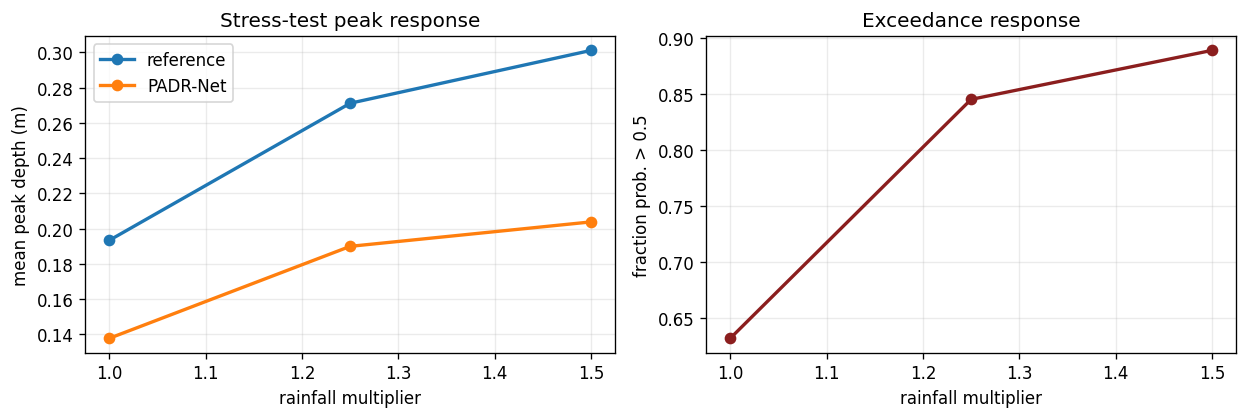

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
f = [r["factor"] for r in rows]
axes[0].plot(f, [r["reference"] for r in rows], "o-", lw=2, label="reference")
axes[0].plot(f, [r["pred"] for r in rows], "o-", lw=2, label="PADR-Net")
axes[0].set_xlabel("rainfall multiplier"); axes[0].set_ylabel("mean peak depth (m)")
axes[0].set_title("Stress-test peak response"); axes[0].legend()
axes[1].plot(f, [r["exceed"] for r in rows], "o-", lw=2, color="#8b1e1e")
axes[1].set_xlabel("rainfall multiplier"); axes[1].set_ylabel("fraction prob. > 0.5")
axes[1].set_title("Exceedance response")
fig.tight_layout(); plt.show()


---

## Exercises

### Exercise 1: Harder transfer

Hold out one region and one later period simultaneously. Which target
region has the largest performance drop relative to the baseline?

### Exercise 2: Warning threshold operations

Use the threshold curve to choose a threshold maximizing `TSS`, then
recompute CSI and mass bias at that threshold.

### Exercise 3: Uncertainty screening

Flag events whose MC-dropout interval width is above the 90th
percentile. Are those events concentrated in one region?

### Exercise 4: Real scenario forcing

Replace the synthetic storm multipliers with real rainfall ensemble or
climate perturbation members. The stress-test code remains unchanged if
`X`, `S`, and `Y` keep the PADR-Net shapes.


---

## Summary

This advanced workflow turns PADR-Net into a compact experiment suite:

1. baseline temporal evaluation;
2. leave-one-region-out transfer;
3. physics-loss ablation;
4. threshold calibration;
5. MC-dropout uncertainty;
6. rainfall-intensification stress testing.

These diagnostics make PADR-Net results easier to defend in papers and
operational reports.
